In [1]:
import tensorflow as tf
from tensorflow import keras

if not tf.config.list_physical_devices('GPU'):
    print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

Go to Runtime > Change runtime and select a GPU hardware accelerator.


In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

4422102/4422102 [==============================] - 0s 0us/step


In [3]:
X_train, X_validation = X_train[:-5000], X_train[-5000:]
y_train, y_validation = y_train[:-5000], y_train[-5000:]

In [4]:
model = keras.models.Sequential([
    keras.layers.Conv2D(filters=32, kernel_size=5, input_shape=[28, 28, 1], activation='relu'),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(filters=64,kernel_size=3, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dense(units=10, activation='softmax')
])

In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 24, 24, 32)        832       
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 12, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 10, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 128)               2

In [6]:
optimizer= tf.keras.optimizers.Adam(learning_rate=0.01,weight_decay=0.01)

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [7]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_validation, y_validation))

Epoch 1/20
1719/1719 [==============================] - 38s 21ms/step - loss: 0.9748 - accuracy: 0.7728 - val_loss: 0.5500 - val_accuracy: 0.8024
Epoch 2/20
1719/1719 [==============================] - 29s 17ms/step - loss: 0.5214 - accuracy: 0.8120 - val_loss: 0.4994 - val_accuracy: 0.8208
Epoch 3/20
1719/1719 [==============================] - 29s 17ms/step - loss: 0.5196 - accuracy: 0.8167 - val_loss: 0.5087 - val_accuracy: 0.8206
Epoch 4/20
1719/1719 [==============================] - 30s 18ms/step - loss: 0.5353 - accuracy: 0.8105 - val_loss: 0.5241 - val_accuracy: 0.8072
Epoch 5/20
1719/1719 [==============================] - 29s 17ms/step - loss: 0.5453 - accuracy: 0.8089 - val_loss: 0.6285 - val_accuracy: 0.7856
Epoch 6/20
1719/1719 [==============================] - 29s 17ms/step - loss: 0.5436 - accuracy: 0.8074 - val_loss: 0.5605 - val_accuracy: 0.8040
Epoch 7/20
1719/1719 [==============================] - 29s 17ms/step - loss: 0.5629 - accuracy: 0.8033 - val_loss: 0.5159 -

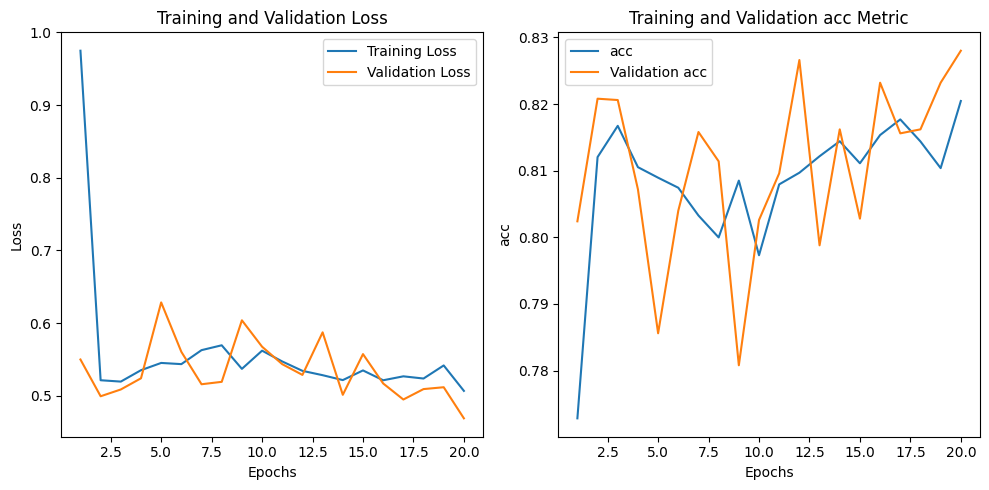

In [8]:
import matplotlib.pyplot as plt

# Extrair métricas de treinamento e validação
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Criar gráfico
epochs = range(1, len(loss_values) + 1)

# Plot da perda
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)  # Cria uma subtrama com 1 linha e 2 colunas (gráfico da perda à esquerda)
plt.plot(epochs, loss_values, label='Training Loss')
plt.plot(epochs, val_loss_values, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot da métrica personalizada
plt.subplot(1, 2, 2)  # Cria uma subtrama com 1 linha e 2 colunas (gráfico da métrica personalizada à direita)
plt.plot(epochs, acc, label='acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and Validation acc Metric')
plt.xlabel('Epochs')
plt.ylabel('acc')
plt.legend()

plt.tight_layout()  # Garante que os gráficos não se sobreponham
plt.show()

In [9]:
score = model.evaluate(X_test, y_test)
print(f'Test accuracy: {score[1]}')  # Index 1 corresponds to the accuracy metric
print(f'Test loss: {score[0]}')

313/313 [==============================] - 2s 5ms/step - loss: 0.5115 - accuracy: 0.8185
Test accuracy: 0.8184999823570251
Test loss: 0.5115209221839905


In [10]:
y_pred = model.predict(X_test)

313/313 [==============================] - 2s 5ms/step


In [11]:
import numpy as np

# Defina o formato de impressão para exibir as probabilidades como porcentagens
np.set_printoptions(formatter={'float': lambda x: "{:.2f}%".format(x * 100)})

print("Probabilidades de Classe em Porcentagem:")
print(y_pred)

Probabilidades de Classe em Porcentagem:
[[0.00% 0.00% 0.00% ... 0.22% 0.00% 99.77%]
 [0.08% 0.04% 93.15% ... 0.00% 0.10% 0.00%]
 [0.00% 99.99% 0.00% ... 0.00% 0.00% 0.00%]
 ...
 [0.00% 0.02% 0.00% ... 0.00% 99.98% 0.00%]
 [0.00% 99.99% 0.00% ... 0.00% 0.00% 0.00%]
 [0.05% 0.01% 0.01% ... 13.46% 0.60% 17.23%]]


In [12]:
y_pred = np.argmax(model.predict(X_test), axis=-1)
y_pred

313/313 [==============================] - 2s 5ms/step


array([9, 2, 1, ..., 8, 1, 5])

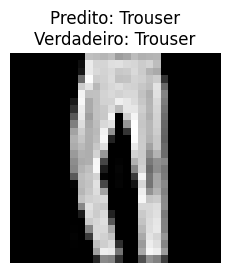

In [13]:
# Mapear os rótulos de classe de números inteiros para nomes de classe legíveis
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Exibir previsões e imagens correspondentes
plt.figure(figsize=(12, 6))


plt.subplot(2, 1, 1)
plt.imshow(X_test[5], cmap='gray')
plt.axis('off')
predicted_label = y_pred[5]
true_label = y_test[5]
plt.title(f"Predito: {class_names[predicted_label]}\nVerdadeiro: {class_names[true_label]}")
plt.show()

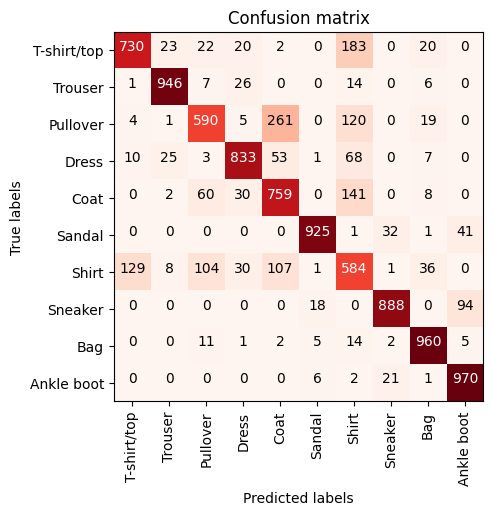

In [14]:
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, class_, title='Confusion matrix', cmap=plt.cm.Reds):
    """
    This function plots a confusion matrix
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    tick_marks = np.arange(len(class_))
    plt.xticks(tick_marks, class_, rotation=90)
    plt.yticks(tick_marks, class_)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True labels')
    plt.xlabel('Predicted labels')
    plt.show()

plot_confusion_matrix(confusion_matrix(y_test, y_pred), list(class_names))